# LMM — Sex classification, Upper third molar

In [5]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [6]:
%%R
install.packages(c("dplyr", "ggplot2", "lme4", "lmerTest", "performance", "readr"),
                  repos = "https://cloud.r-project.org", quiet = TRUE)

## 1. Load and prepare data

In [7]:
%%R
library(dplyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(performance)

data <- read.csv("data/sex_upper_third_molar.csv")

# Factor encoding
data$patient_id <- as.factor(data$patient_id)
data$class      <- as.factor(data$class)   # "female" / "male"

cat("Observations :", nrow(data), "\n")
cat("Patients     :", n_distinct(data$patient_id), "\n")

Observations : 682 
Patients     : 40 


## 2. Filter: keep only perturbation steps that changed model decision

- XI (X Increase) : prob_change > 0
- XD (X Decrease) : prob_change < 0

In [8]:
%%R
XI <- subset(data, prob_change > 0)
XD <- subset(data, prob_change < 0)
data_combined <- rbind(XI, XD)

cat("Observations after filter :", nrow(data_combined), "\n")
cat("Patients after filter     :", n_distinct(data_combined$patient_id), "\n")

# Verify no patient appears in both classes (should be 0)
data_combined %>%
  group_by(patient_id) %>%
  summarise(n_classes = n_distinct(class)) %>%
  filter(n_classes > 1) %>%
  nrow() %>%
  cat("Patients with both classes:", ., "\n")


Observations after filter : 682 
Patients after filter     : 40 
Patients with both classes: 18 


## 3. Descriptive statistics

In [9]:
%%R
summary_table <- data_combined %>%
  group_by(class) %>%
  summarise(
    n_patients = n_distinct(patient_id),
    n_obs      = n(),
    mean       = round(mean(width_adj_mm), 2),
    sd         = round(sd(width_adj_mm), 2),
    min        = round(min(width_adj_mm), 2),
    max        = round(max(width_adj_mm), 2)
  )
print(summary_table)

# A tibble: 2 × 7
  class  n_patients n_obs  mean    sd   min   max
  <fct>       <int> <int> <dbl> <dbl> <dbl> <dbl>
1 female         24   100  12.6  1.66  10.0  16.1
2 male           34   582  15.1  2.08   9    20.1


## 4. Fit Linear Mixed-Effects Model (LMER via lme4)

Fixed effect : class — sex (female / male)
Random effect: random intercept per patient

In [11]:
%%R
model <- lmer(width_adj_mm ~ class + (1 | patient_id),
              data = data_combined)

summary(model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: width_adj_mm ~ class + (1 | patient_id)
   Data: data_combined

REML criterion at convergence: 2332.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.59725 -0.66085  0.02498  0.70223  2.66681 

Random effects:
 Groups     Name        Variance Std.Dev.
 patient_id (Intercept) 2.346    1.532   
 Residual               1.496    1.223   
Number of obs: 682, groups:  patient_id, 40

Fixed effects:
            Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)  12.3409     0.2793  60.9245   44.18   <2e-16 ***
classmale     2.6586     0.1669 679.6975   15.93   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
          (Intr)
classmale -0.443


## 5. Assumption checks

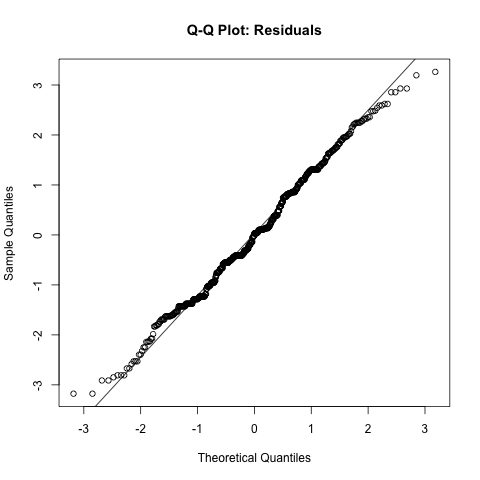

In [12]:
%%R
# 5a. Normality of residuals — Q-Q plot
res <- resid(model)

qqnorm(res, main = "Q-Q Plot: Residuals")
qqline(res)

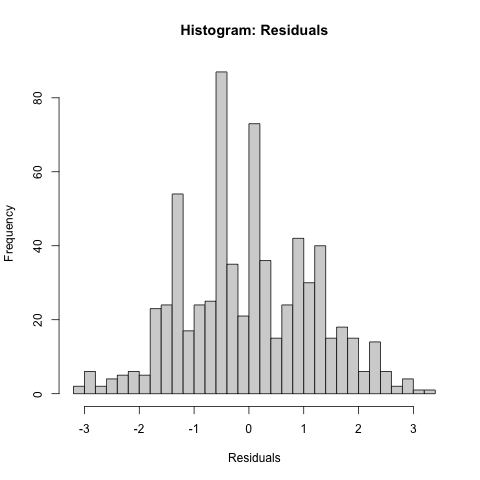

In [13]:
%%R
# 5b. Normality of residuals — Histogram
hist(res, breaks = 30, main = "Histogram: Residuals", xlab = "Residuals")

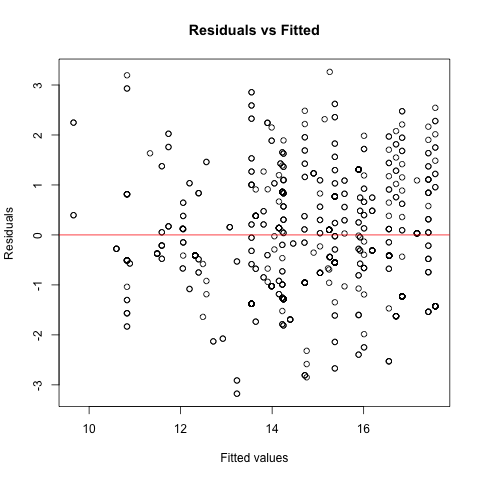

In [14]:
%%R
# 5c. Homoscedasticity — Residuals vs Fitted
plot(fitted(model), res,
     xlab = "Fitted values", ylab = "Residuals",
     main = "Residuals vs Fitted")
abline(h = 0, col = "red")

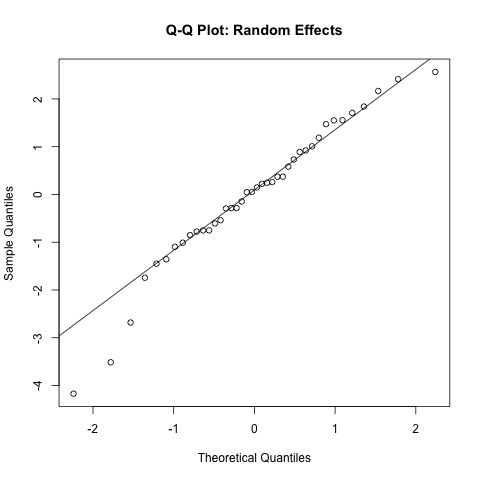

In [15]:
%%R
# 5d. Normality of random effects
ranef_vals <- ranef(model)$patient_id[, 1]
qqnorm(ranef_vals, main = "Q-Q Plot: Random Effects")
qqline(ranef_vals)

## 6. Inference
Fixed-effects ANOVA table (Type III)

In [16]:
%%R
anova(model)

Type III Analysis of Variance Table with Satterthwaite's method
      Sum Sq Mean Sq NumDF DenDF F value    Pr(>F)    
class 379.63  379.63     1 679.7  253.76 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [17]:
%%R
# Predicted marginal means per sex (population-level, re.form = NA)
newdata <- data.frame(class = c("female", "male"))
newdata$predicted <- predict(model, newdata, re.form = NA)
print(newdata)

   class predicted
1 female  12.34094
2   male  14.99959


In [18]:
%%R
# R-squared
r2(model)

# R2 for Mixed Models

  Conditional R2: 0.684
     Marginal R2: 0.187
